## Rental Yield Analysis & Interest Rate Sensitivity
This notebook analyses suburb-level gross rental yields across Melbourne by integrating cleaned rental and price datasets. It examines yield distribution, the relationship between house prices and rental yields, and regional patterns, and sensitivity to interest rate changes, with the aim of deriving investment-relevant insights into income potential and risk.

In [5]:
import pandas as pd 

#loading final yield dataset 
df = pd.read_csv("../data/processed/suburb_house_rental_yield.csv")
df.head()


,region,suburb,median_rent,property_type,median_price,sales_count,gross_yield,gross_yield_pct
0,Inner Melbourne,Armadale,1100.0,3 Bed House,2588000.0,20,0.022102,2.210201
1,Inner Melbourne,Carlton North,930.0,3 Bed House,1730000.0,20,0.027954,2.795376
2,Inner Melbourne,East Melbourne,1200.0,3 Bed House,1696000.0,2,0.036792,3.679245
3,Inner Melbourne,Elwood,1000.0,3 Bed House,2542500.0,20,0.020452,2.045231
4,Inner Melbourne,Fitzroy,1100.0,3 Bed House,1600000.0,24,0.035750,3.575000


In [ ]:
df.describe()
#Analysis for 77 suburbs where 3 bed houses are observable 

#Median_Rent Column
#mean = $658/week
#median = $580/week
#range = $380 -> $1250/weel
#Interpretation: mean > median, which suggests some high-rent suburbs (likely inner or premium areas) that are pulling the average up 
#Weekly rents for 3-bed houses vary substantially across melbourne, reflecting strong segmentation in the rental market 


#Median_Price Column
#Median price of houses is $902,000
#Mean price of houses is $1.21m 
#Ranges from $351k - $3.43m
#Interpretation: mean > median, this indicates that a small number of very expensive suburbs are skewing the average 
#Median suburb in dataset is still around $1m
#Wide range reflects melbourne's highly heterogeneous housing market, this highlights the importance of suburb selection in residential investment analysis

#Gross Yield Pct Column 
#Mean yield is 3.40%
#Median yield is 3.47%
#25% percentile: 2.57%
#75% percentile: 4.09%
#Median melbourne suburb in this sample yields approximately 3.5% gross 
#Bottom quartile: low yield, high price suburbs 
#Top quartle: higher yield, more affordable suburbs/areas 

#Overall:
#Across the analysed suburbs, gross rental yields for 3-bed houses range from approximately 1.2% to 5.9%, with median yield of 3.5%. This dispersion reflects the significant variation in the balance between rental income and capital values across Melbourne. 
#While high-yield suburbs exists, they represent a minority  of the market, with most suburbs clustering between 2.5% and 4%. This highlights the importance of suburb selection for investors seeking income resilience, particularly in high interest rate environments. 

,median_rent,median_price,sales_count,gross_yield,gross_yield_pct
count,77.000000,7.700000e+01,77.000000,77.000000,77.000000
mean,658.454545,1.213447e+06,57.428571,0.033963,3.396312
std,221.110210,7.723421e+05,51.890175,0.010676,1.067645
min,380.000000,3.510000e+05,2.000000,0.012161,1.216129
25%,490.000000,6.200000e+05,24.000000,0.025698,2.569767
50%,580.000000,9.020000e+05,36.000000,0.034715,3.471539
75%,793.000000,1.635000e+06,68.000000,0.040904,4.090377
max,1250.000000,3.425000e+06,247.000000,0.059259,5.925926


In [8]:
#Diagrams for Analysis 
#Distribution of Rental Yields 

import matplotlib.pyplot as plt


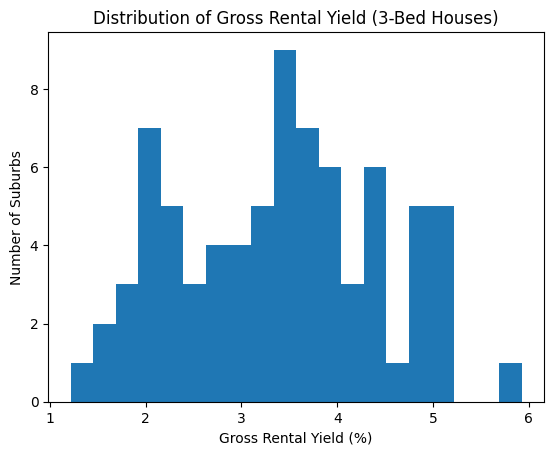

In [ ]:
plt.figure()
plt.hist(df["gross_yield_pct"], bins=20)
plt.xlabel("Gross Rental Yield (%)")
plt.ylabel("Number of Suburbs")
plt.title("Distribution of Gross Rental Yield (3-Bed Houses)")
plt.show()

#Interpretation: distribution of gross rental yield for 3-bed houses across melb shows clear concentration between 2-4%, with median yield around 3.5%
#While higher yield suburbs exists, yields above 5% quite uncommon, indicating that income-focused opportunities are concentrated in smaller subset of locations 
#Slight right skew highlights trade-off between rental income and capital value across suburbs, reinforcing importnace of targeted suburb selection in investment analysis 
#TLDR: yields mainly cluster around 3-4%; high-yield suburbs exists, but they are the exception, not the rule in melbourne 

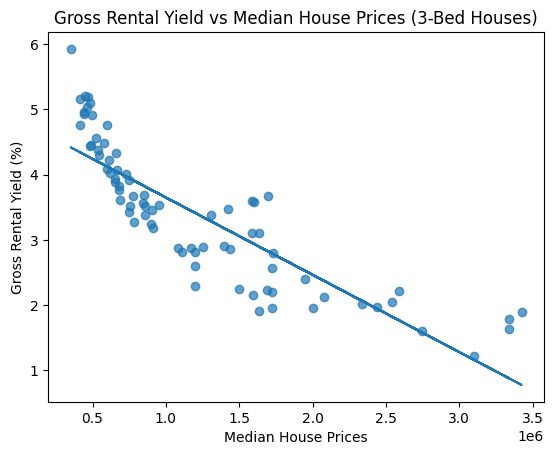

In [19]:
#What do yields look like? and what is driving them?
plt.figure()
plt.scatter(
    df["median_price"],
    df["gross_yield_pct"],
    alpha=0.7
)
plt.plot(x,trend(x)) #Trend line for clearer observation 
plt.xlabel("Median House Prices")
plt.ylabel("Gross Rental Yield (%)")
plt.title("Gross Rental Yield vs Median House Prices (3-Bed Houses)")
plt.show()

#Seems like there is a negative/inverse relationship (higher prices, lower yield)
#There is yield compression in high-priced suburbs 
#Higher yields concentrated in more affordable suburbs/areas with weaker capital growth expectations 


In [ ]:
#Quantifying the inverse relationship - computing the correlation between price and yield 
df[["median_price","gross_yield_pct"]].corr()

#-0.86 correlation suggest very strong inverse relationship 
#Higher-priced suburbs consistently exhibit lower income returns, suggesting that rental yields are primarily driven by capital values rather than proportional increases in rent 

,median_price,gross_yield_pct
median_price,1.000000,-0.856738
gross_yield_pct,-0.856738,1.000000


In [ ]:
df.sort_values("gross_yield_pct", ascending=False).head(10)
#high yield suburbs almost entirely in regional centres - offer stronger income returns (Morwell, Shepparton, Mildura)
#moderate to high sales counts - supports reliability of observed medians 
#relatively low prices 
#rents are not proportionally low to prices 

,region,suburb,median_rent,property_type,median_price,sales_count,gross_yield,gross_yield_pct
66,Other Regional Centres,Morwell,400.0,3 Bed House,351000.0,96,0.059259,5.925926
59,Other Regional Centres,Bairnsdale,450.0,3 Bed House,450000.0,35,0.052000,5.200000
69,Other Regional Centres,Shepparton,470.0,3 Bed House,470500.0,188,0.051945,5.194474
64,Other Regional Centres,Horsham,410.0,3 Bed House,413100.0,68,0.051610,5.160978
65,Other Regional Centres,Mildura,475.0,3 Bed House,485000.0,165,0.050928,5.092784
60,Other Regional Centres,Benalla,450.0,3 Bed House,465000.0,55,0.050323,5.032258
67,Other Regional Centres,Portland,425.0,3 Bed House,445000.0,57,0.049663,4.966292
68,Other Regional Centres,Seymour,420.0,3 Bed House,443000.0,27,0.049300,4.930023
58,Bendigo,North Bendigo,470.0,3 Bed House,497500.0,23,0.049126,4.912563
75,Other Regional Centres,Warrnambool,550.0,3 Bed House,600000.0,122,0.047667,4.766667


In [ ]:
df.sort_values("gross_yield_pct").head(10)
#low yield suburbs exclusively almost near inner and premium melbourn suburbs - offer capital stability and desirability 
#very high median prices (strong capital desirability) - Toorak, Balwyn, Brighton
#high owner-occupier demand due to proximity to CBD (maybe)

#At the end of the day, choice reflects investment objective, not quality 
#There is a trade-off between income generation and capital exposure across Melb residential market 

,region,suburb,median_rent,property_type,median_price,sales_count,gross_yield,gross_yield_pct
10,Inner Eastern Melbourne,Balwyn,725.0,3 Bed House,3100000.0,31,0.012161,1.216129
15,Inner Eastern Melbourne,Kew,845.0,3 Bed House,2745000.0,54,0.016007,1.600729
24,Southern Melbourne,Malvern,1050.0,3 Bed House,3340000.0,20,0.016347,1.634731
18,Southern Melbourne,Brighton,1150.0,3 Bed House,3341800.0,58,0.017895,1.789455
9,Inner Melbourne,Toorak,1250.0,3 Bed House,3425000.0,9,0.018978,1.897810
11,Inner Eastern Melbourne,Blackburn,600.0,3 Bed House,1638000.0,28,0.019048,1.904762
25,Southern Melbourne,Malvern East,750.0,3 Bed House,2000000.0,51,0.019500,1.950000
12,Inner Eastern Melbourne,Box Hill,650.0,3 Bed House,1725000.0,7,0.019594,1.959420
14,Inner Eastern Melbourne,Hawthorn,925.0,3 Bed House,2440000.0,26,0.019713,1.971311
19,Southern Melbourne,Brighton East,905.0,3 Bed House,2337500.0,42,0.020133,2.013262


In [27]:
#Segmenting the market 
df["yield_quartile"] = pd.qcut(df["gross_yield_pct"], 4, labels=["Low Yield","Mid-Low Yield", "Mid-High Yield","High Yield" ])

In [28]:
df

,region,suburb,median_rent,property_type,median_price,sales_count,gross_yield,gross_yield_pct,yield_quartile
0,Inner Melbourne,Armadale,1100.0,3 Bed House,2588000.0,20,0.022102,2.210201,Low Yield
1,Inner Melbourne,Carlton North,930.0,3 Bed House,1730000.0,20,0.027954,2.795376,Mid-Low Yield
2,Inner Melbourne,East Melbourne,1200.0,3 Bed House,1696000.0,2,0.036792,3.679245,Mid-High Yield
3,Inner Melbourne,Elwood,1000.0,3 Bed House,2542500.0,20,0.020452,2.045231,Low Yield
4,Inner Melbourne,Fitzroy,1100.0,3 Bed House,1600000.0,24,0.035750,3.575000,Mid-High Yield
...,...,...,...,...,...,...,...,...,...
72,Other Regional Centres,Traralgon,450.0,3 Bed House,535000.0,136,0.043738,4.373832,High Yield
73,Other Regional Centres,Wangaratta,460.0,3 Bed House,525000.0,89,0.045562,4.556190,High Yield
74,Other Regional Centres,Warragul,480.0,3 Bed House,620000.0,102,0.040258,4.025806,Mid-High Yield
75,Other Regional Centres,Warrnambool,550.0,3 Bed House,600000.0,122,0.047667,4.766667,High Yield


C:\Users\trabi\AppData\Local\Temp\ipykernel_30380\520752313.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["region","yield_quartile"])


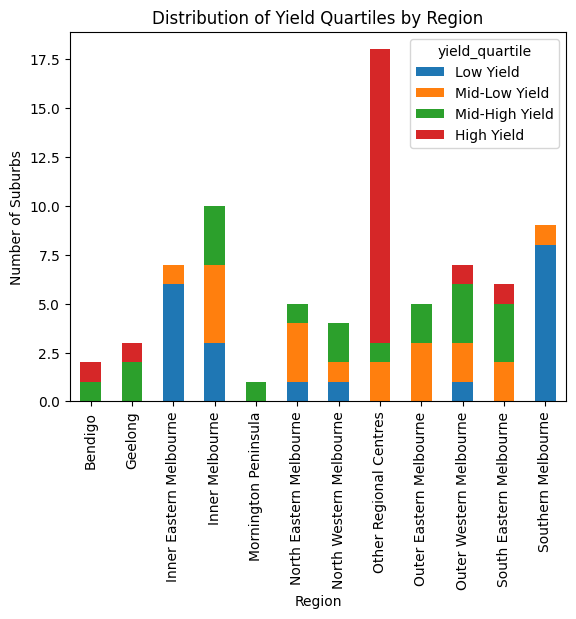

In [40]:
#Regions that dominate the high-yield buckets

summary = (
    df.groupby(["region","yield_quartile"])
    .size()
    .unstack(fill_value=0)
)

summary.plot(kind="bar", stacked=True)
plt.xlabel("Region")
plt.ylabel("Number of Suburbs")
plt.title("Distribution of Yield Quartiles by Region")
plt.xticks(rotation=90)
plt.show()

#observation: ORC dominates the high yield bucket 

## Key Findings 

1. **Rental yields across Melbourne suburbs are tightly clustered but meaningfully dispersed.**
Gross rental yields for 3-Bed houses cluster primarily between 2.5% and 4.0%, with a median yield of roughly 3.5%. While extreme outcomes exists, yield variation is continuous rather than segmented, suggesting incremental suburb selection plays a meaningful role in income outcomes. 

2. **House prices are the primary driver of yield variation.**
There is a strong inverse relationship between median house prices and gross rental yields (Correlation = -0.86). This indicates that yield compression in higher-priced suburbs is structural rather than incidental, with rental income failing to scale proportionally with capital values.

3. **High-yield suburbs are concentrated in regional centres of Melbourne.**
Suburbs at the upper end of the yield distribution (5% and above) are predominantly in regional centres, such as Morwell, Shepparton, and Mildura. These locations combine lower entry prices with stable rental demand, resulting in stronger income returns, compared to inner and more premium suburbs within Melbourne. 

4. **Low-yield suburbs reflect capital-dominant investment profiles.**
Premium inner Melbourne suburbs, including Toorak, Balwyn, and Brighton, exhibit gross rental yields below 2% despite high absolute rents. Elevated capital values drive signficant yield compression, suggeseting these markets prioritise capital preservation and growth over income generation. 

5. **Yield outcomes reflect investment trade-offs rather than market inefficiencies.** 
The observed yield dispersion highlights a clear trade-off between income return and capital exposure. Higher yields are associated with more affordable markets, while lower yields align with capital desirability, reinforcing the importance of aligning suburb selection with investment objectives. 

## Interest Rate Sensitivity Analysis 
Rising interest rates materially alter the relative attractiveness of residential property investments by increasing borrowing costs. While rental yields vary across suburbs, interest rates affect all investors simultaneously, amplifying the importance of income return in higher interest rate environments. 

This section evaluates how observed suburb level rental yields compare against prevailing interest rate scenarios, with the aim of assessing relative income resilience and exposure under different macroeconomic conditions. 


## Interest Rate Context

As of 10 December 2025, the Reserve Bank of Australia (RBA) cash rate stands at 3.60%. While the cash rate provides an important indicator for overall monetary policy setting, it does not directly reflect the borrowing costs faced by residential property investors. 

Mortgage rates typically incorporate a spread above the cash rate, reflecting bank funding costs, risk premiums, and lending margins. As a result, investors borrowing costs are materially higher than the headlined cash rate by the RBA.



## Interest Rate Scenarios

Three interest rate environments are considered to assess income resilience under realistic financing conditions: 

- **Low-rate environment:** 3.0% mortgage rate 
- **Current-rate environment:** 5.5% mortgage rate 
- **High-rate environment:** 7.0% mortgage rate 

These scenarios are not forecasts, but benchmarks used to compare rental income against borrowing costs under varying monetary conditions. 

In [ ]:
#Computing yield-rate spread

interest_scenarios = {
    "low_rate": 0.03,
    "current_rate": 0.055, 
    "high_rate": 0.07
}

for name, rate in interest_scenarios.items():
    df[f"spread_{name}"] = df["gross_yield"] - rate #rental yield - borrowing costs (to see if rental income covers the cost of debt)

df[
    ["suburb","gross_yield_pct","spread_low_rate","spread_current_rate","spread_high_rate"]
].head(50)

,suburb,gross_yield_pct,spread_low_rate,spread_current_rate,spread_high_rate
0,Armadale,2.210201,-0.007898,-0.032898,-0.047898
1,Carlton North,2.795376,-0.002046,-0.027046,-0.042046
2,East Melbourne,3.679245,0.006792,-0.018208,-0.033208
3,Elwood,2.045231,-0.009548,-0.034548,-0.049548
4,Fitzroy,3.575000,0.005750,-0.019250,-0.034250
5,Port Melbourne,3.100917,0.001009,-0.023991,-0.038991
6,South Melbourne,3.106918,0.001069,-0.023931,-0.038931
7,South Yarra,3.597484,0.005975,-0.019025,-0.034025
8,St Kilda,3.471539,0.004715,-0.020285,-0.035285
9,Toorak,1.897810,-0.011022,-0.036022,-0.051022


: 

In [1]:
df_spreads = df[
    [
        "suburb",
        "gross_yield_pct",
        "yield_quartile",
        "spread_low_rate",
        "spread_current_rate",
        "spread_high_rate"
    ]
].copy()

df_spreads.to_csv(
    "../data/processed/suburb_yield_rate_spreads.csv",
    index=False
)

NameError: name 'df' is not defined

### Interpretating Suburb Level Yield Rate Spreads 

The yield-rate spread measures the difference between a suburb's gross rental yield and the cost of borrowing under different interest rate environments. A positive spread indicates that rental income is sufficient to cover borrowing costs, while negative spread implies that the investment is income-negative and relies on capital growth to justify returns. 

Across most inner and premium Melbourne suburbs, rental yields are relatively low compared to property prices. As a result, these suburbs exhibit negative yield-rate spreads even in low rate environments. For instance, suburbs such as Toorak, Kew, Balwyn, and Brighton remain income-negative across all scenarios, indicating a strong dependence on capital appreciation rather than rental income. 

In contrast, a number of middle and outer suburbs display higher rental yields. While these suburbs still become income-negative as interest rates rises, the magnitude of income shortfall is smaller. Suburbs such as Craigieburn, Cranbourne, Melton, and Dandenong approach breakeven in low interest rate environment and retain comparatively smaller funding gaps under current and high-rate scenarios.

Overall, the suburb level results highlight that interest rate increases do not affect all markets equally. Lower yield, high priced suburbs experience larger and more immediate income-shortfalls, whil higher-yield suburbs demonstrate greater resilience to borrowing costs.

In [42]:
#Impact by yield group - to detemine who gets hit first as rates rises 
df.groupby("yield_quartile")[
    ["spread_low_rate","spread_current_rate","spread_high_rate"]
].mean()

C:\Users\trabi\AppData\Local\Temp\ipykernel_30380\381318903.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("yield_quartile")[


,spread_low_rate,spread_current_rate,spread_high_rate
yield_quartile,,,
Low Yield,-0.009788,-0.034788,-0.049788
Mid-Low Yield,0.000780,-0.024220,-0.039220
Mid-High Yield,0.007628,-0.017372,-0.032372
High Yield,0.017956,-0.007044,-0.022044


### Impact of Interest Rate Changes by Yield Group 

Grouping suburbs by yield level reveals clear differences in how interest rate changes affect income performance. Low-yield suburbs are income-negative even in low interest rate environments and experience rapidly widening funding gaps as rates rises.This indicates strong reliance on capital growth assumptions and great exposure to tightening financial conditions. 

Mid-Yield suburbs tend to be close to breakeven only under low-rate scenarios, but quickly become income-negative as borrowing costs normalise/increases. These areas demonstrate moderate sensitivity to interest rate changes. 

High-yield suburbs exhibit the greatest income resilience. While they are not immune to higher interest rates, their funding gap remain smaller than those observed in lower-yield markets. In low rate environments, some high-yield suburbs may even approach or exceed breakeven on an income basis. 

Overall, rising interest rates impact low-yield suburbs disproportionately, while higher-yield suburbs are much better positioned to absorb increases in borrowing costs. 

## Core Insights 

- Rental yields vary significantly across Melbourne suburbs, largely driven by differences in house prices rather than rental levels.
- High-priced inner and premium suburbs tend to generate low rental yields, meaning rental incomedoes not keep up with property values.
- When interest rates are low, a small number of suburbs are able to cover most of their borrowing costs through rental income. 
- Low-yield suburbs experience the largest funding gaps and are most exposed to rising interest rates, relying heavily on capital growth to justify their returns. 
- Higher-yield suburbs remain more resilient from an income perspective and experience smaller shortfalls as borrowing costs increase. 
- Overall, rising interest rates shift the balance of risk and return, increasing the relative importance of rental income and highlighting clear trade-offs between income resilience and capital exposure.